In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# data visualisation and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

import tensorflow
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
from keras.preprocessing import image

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation,Lambda
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 
import tensorflow as tf
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import cv2                  
import numpy as np  
from tqdm import tqdm
import os                   
from random import shuffle  
from zipfile import ZipFile
from PIL import Image

In [48]:
import lzma

import tarfile

import tarfile

input_path_test = "/kaggle/input/gan-2024-assignment-1/gan_test.tar.xz/gnr_test.tar.xz"
output_path_test = "/kaggle/working/test"  # Writable directory

# Extract to /kaggle/working/
with tarfile.open(input_path_test, "r:xz") as tar:
    tar.extractall(output_path_test)  # Extracts images to the working directory
    tar.list()  # Lists contents




?rw-rw-r-- uesr/uesr      16202 2017-05-02 20:04:54 101.jpg 
?rw-rw-r-- uesr/uesr      70477 2017-04-18 03:59:28 102.jpg 
?rw-rw-r-- uesr/uesr      21514 2017-05-03 20:56:52 103.jpg 
?rw-rw-r-- uesr/uesr      15340 2017-05-02 20:04:54 104.jpg 
?rw-rw-r-- uesr/uesr      57002 2017-05-02 23:31:28 105.jpg 
?rw-rw-r-- uesr/uesr      70107 2017-04-21 09:27:22 106.jpg 
?rw-rw-r-- uesr/uesr      68097 2017-04-18 03:59:28 107.jpg 
?rw-rw-r-- uesr/uesr      14902 2017-04-19 21:02:24 108.jpg 
?rw-rw-r-- uesr/uesr      14553 2017-05-09 02:13:00 109.jpg 
?rw-rw-r-- uesr/uesr      14931 2017-05-09 02:13:00 110.jpg 
?rw-rw-r-- uesr/uesr      53142 2017-05-02 23:31:28 111.jpg 
?rw-rw-r-- uesr/uesr      58242 2017-04-21 09:27:22 112.jpg 
?rw-rw-r-- uesr/uesr      16739 2017-05-02 20:04:54 113.jpg 
?rw-rw-r-- uesr/uesr      20554 2017-04-28 07:47:50 114.jpg 
?rw-rw-r-- uesr/uesr      57778 2017-04-27 01:48:48 115.jpg 
?rw-rw-r-- uesr/uesr      84414 2017-05-01 19:18:14 116.jpg 
?rw-rw-r-- uesr/uesr    

In [8]:

input_path_train = "/kaggle/input/gan-2024-assignment-1/gan_train.tar.xz/gnr_train.tar.xz"
output_path_train = "/kaggle/working"  # Writable directory

# Extract to /kaggle/working/
with tarfile.open(input_path_train, "r:xz") as tar:
    tar.extractall(output_path_train)  # Extracts images to the working directory
    tar.list()  # Lists contents


?rwxr-xr-x uesr/uesr          0 2021-08-28 04:15:26 train/ 
?rwxrwxr-x uesr/uesr          0 2021-08-28 04:24:04 train/bridge/ 
?rw-rw-r-- uesr/uesr      14860 2017-05-09 02:12:54 train/bridge/001.jpg 
?rw-rw-r-- uesr/uesr      15614 2017-05-09 02:12:54 train/bridge/002.jpg 
?rw-rw-r-- uesr/uesr      16380 2017-05-09 02:12:54 train/bridge/003.jpg 
?rw-rw-r-- uesr/uesr      15729 2017-05-09 02:12:54 train/bridge/004.jpg 
?rw-rw-r-- uesr/uesr      14892 2017-05-09 02:12:54 train/bridge/005.jpg 
?rw-rw-r-- uesr/uesr      13722 2017-05-09 02:12:54 train/bridge/006.jpg 
?rw-rw-r-- uesr/uesr      13957 2017-05-09 02:12:54 train/bridge/007.jpg 
?rw-rw-r-- uesr/uesr      14271 2017-05-09 02:12:54 train/bridge/008.jpg 
?rw-rw-r-- uesr/uesr      14512 2017-05-09 02:12:54 train/bridge/009.jpg 
?rw-rw-r-- uesr/uesr      15301 2017-05-09 02:12:54 train/bridge/010.jpg 
?rw-rw-r-- uesr/uesr      14775 2017-05-09 02:12:54 train/bridge/011.jpg 
?rw-rw-r-- uesr/uesr      15729 2017-05-09 02:12:54 train/b

In [9]:
# directories:
train_dir="/kaggle/working/train"
test_dir="/kaggle/working/test"

X=[]
Z=[]
IMG_SIZE=150

basket_dir="/kaggle/working/train/basketball_court"
bridge_dir="/kaggle/working/train/bridge"
crosswalk_dir="/kaggle/working/train/crosswalk"
golf_dir="/kaggle/working/train/golf_course"
oil_dir="/kaggle/working/train/oil_well"
overpass_dir="/kaggle/working/train/overpass"
railway_dir="/kaggle/working/train/railway"
runway_dir="/kaggle/working/train/runway"
swimming_dir="/kaggle/working/train/swimming_pool"
tennis_dir="/kaggle/working/train/tennis_court"








In [5]:
def assign_label(img,xray_type):
    return xray_type

def make_train_data(xray_type,DIR):
    for img in tqdm(os.listdir(DIR)):
        label=assign_label(img,xray_type)
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR) 
        #now it is an array
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        
        X.append(np.array(img))
        Z.append(str(label))
        

In [10]:
L=[basket_dir,bridge_dir, crosswalk_dir, golf_dir, oil_dir, overpass_dir, railway_dir, runway_dir, swimming_dir, tennis_dir]

print(L)
Names_dir=['basket_dir','bridge_dir', 'crosswalk_dir', 'golf_dir', 'oil_dir', 'overpass_dir', 'railway_dir', 'runway_dir', 'swimming_dir', 'tennis_dir']

['/kaggle/working/train/basketball_court', '/kaggle/working/train/bridge', '/kaggle/working/train/crosswalk', '/kaggle/working/train/golf_course', '/kaggle/working/train/oil_well', '/kaggle/working/train/overpass', '/kaggle/working/train/railway', '/kaggle/working/train/runway', '/kaggle/working/train/swimming_pool', '/kaggle/working/train/tennis_court']


In [11]:
X=[]
Z=[]
Names=[]
Names=[name.split("_")[0] for name in Names_dir]
for i in range(len(L)): 
    make_train_data(Names[i],L[i])
    print(len(X))

100%|██████████| 50/50 [00:00<00:00, 789.37it/s]


50


100%|██████████| 50/50 [00:00<00:00, 1282.14it/s]


100


100%|██████████| 50/50 [00:00<00:00, 1251.07it/s]


...

400


100%|██████████| 50/50 [00:00<00:00, 530.33it/s]


450


100%|██████████| 50/50 [00:00<00:00, 1180.38it/s]

500


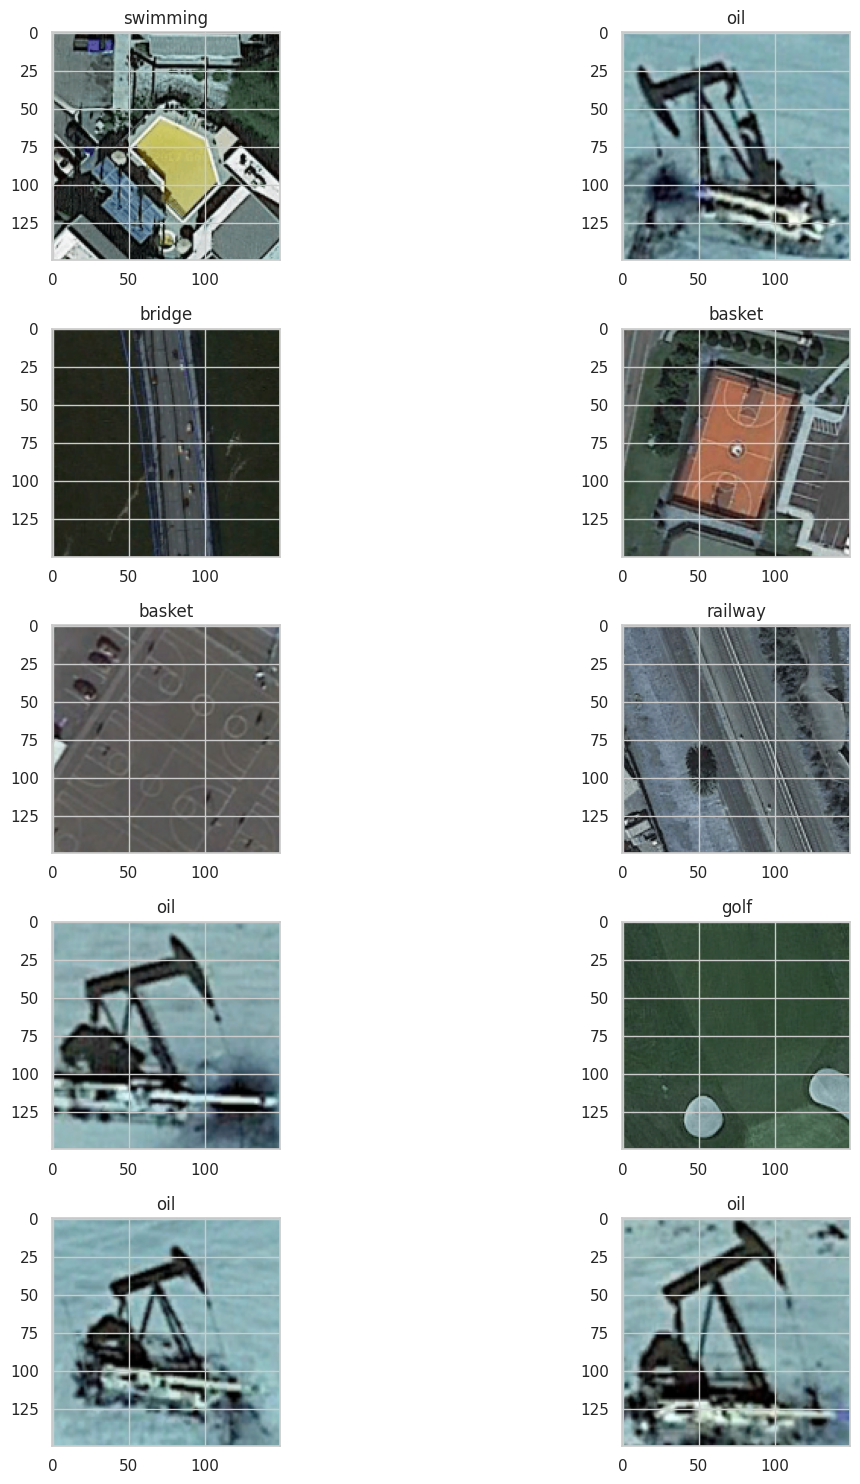

In [45]:
fig,ax=plt.subplots(5,2)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (2):
        l=rn.randint(0,len(Z)-1)
        ax[i,j].imshow(X[l])
        ax[i,j].set_title(Z[l])
        
plt.tight_layout()
# X[:3]

In [13]:
le=LabelEncoder()
Y=le.fit_transform(Z)

Y=to_categorical(Y,10)
print(len(X))
X=np.array(X)
X = X.reshape((500, 150, 150, 3))

print(X[1])

500
[[[177 195 190]
  [171 184 181]
  [169 178 175]
  ...
  [ 57  69  66]
  [ 56  70  66]
  [ 60  74  70]]

 [[155 169 167]
  [144 154 153]
  [133 139 138]
  ...
  [ 50  66  61]
  [ 49  63  57]
  [ 58  72  66]]

 [[132 141 139]
  [129 136 135]
  [126 133 132]
  ...
  [ 80  96  89]
  [ 75  90  83]
  [ 74  87  79]]

 ...

 [[ 67  84  77]
  [ 68  87  78]
  [ 69  88  80]
  ...
  [ 66  65  66]
  [ 67  66  67]
  [ 64  63  64]]

 [[ 69  87  80]
  [ 69  88  79]
  [ 72  91  83]
  ...
  [ 79  76  78]
  [ 82  79  81]
  [ 83  80  82]]

 [[ 70  88  83]
  [ 67  85  78]
  [ 69  86  82]
  ...
  [ 69  66  68]
  [ 69  66  68]
  [ 70  67  69]]]


In [54]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)
batch_size=32
epochs=20

In [15]:
#building the model

model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'same',activation ='relu', input_shape = (150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
 

model.add(Conv2D(filters =96, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters = 96, kernel_size = (3,3),padding = 'same',activation ='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dense(10, activation = "softmax"))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 96)          │          83,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 9, 9, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7776)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,981,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,146,314 (15.82 MB)

 Trainable params: 4,146,314 (15.82 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from keras.callbacks import ReduceLROnPlateau
red_lr= ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.1)

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=True)  # randomly flip images

#make vertical flip true 


datagen.fit(x_train)

In [55]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

History = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_test,y_test),
                              verbose = 1, steps_per_epoch=x_train.shape[0] // batch_size)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 914ms/step - accuracy: 0.6915 - loss: 1.4052 - val_accuracy: 0.4960 - val_loss: 1.3615
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6250 - loss: 1.0217 - val_accuracy: 0.5920 - val_loss: 1.2399
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.7363 - loss: 0.7537 - val_accuracy: 0.8160 - val_loss: 0.6019
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.6562 - loss: 0.9490 - val_accuracy: 0.8400 - val_loss: 0.5151
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 921ms/step - accuracy: 0.7721 - loss: 0.7911 - val_accuracy: 0.8400 - val_loss: 0.5515
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9062 - loss: 0.4150 - val_accuracy: 0.8400 - val_loss: 0.5205
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 916ms/step - accuracy: 0.8262 - loss: 0.4761 - val_accuracy: 0.8000 - val_loss: 0.6133
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.7826 - loss: 0.6142 - val_accuracy: 0

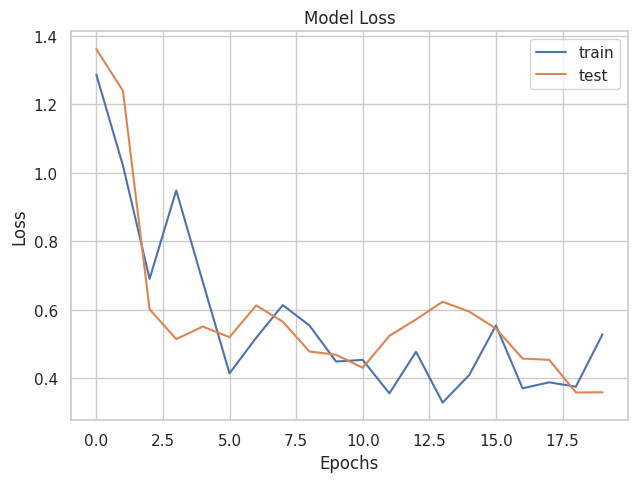

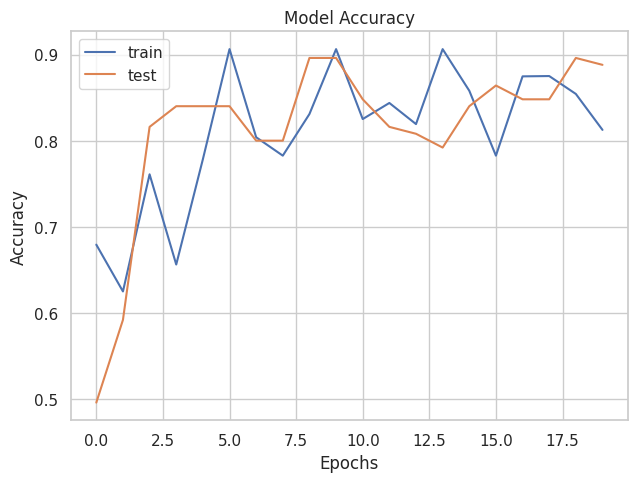

In [56]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

In [57]:


test=[]
# def assign_label(img,xray_type):
#     return xray_type

def make_test_data(DIR):
    for img in tqdm(os.listdir(DIR)):
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR) 
        #now it is an array
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        
        test.append(np.array(img))
        

In [58]:
make_test_data(output_path_test)

100%|██████████| 100/100 [00:00<00:00, 841.09it/s]


In [59]:
print(test[1:2])

[array([[[32, 40, 23],
        [30, 40, 24],
        [23, 33, 18],
        ...,
        [31, 39, 29],
        [24, 32, 21],
        [28, 37, 22]],

       [[29, 36, 21],
        [36, 45, 32],
        [27, 35, 24],
        ...,
        [26, 34, 27],
        [20, 29, 19],
        [26, 37, 22]],

       [[33, 41, 29],
        [42, 48, 39],
        [25, 30, 24],
        ...,
        [31, 39, 32],
        [34, 44, 33],
        [33, 43, 28]],

       ...,

       [[22, 32, 15],
        [23, 35, 17],
        [25, 38, 20],
        ...,
        [41, 42, 38],
        [24, 29, 19],
        [35, 46, 29]],

       [[25, 35, 16],
        [27, 39, 21],
        [29, 40, 24],
        ...,
        [34, 36, 29],
        [31, 36, 24],
        [39, 48, 29]],

       [[21, 30, 11],
        [28, 38, 22],
        [30, 41, 25],
        ...,
        [43, 44, 34],
        [45, 50, 34],
        [41, 49, 29]]], dtype=uint8)]


In [64]:
test=np.array(test)
test=test.reshape(100,150,150,3)
print(test[1:3])

[[[[32 40 23]
   [30 40 24]
   [23 33 18]
   ...
   [31 39 29]
   [24 32 21]
   [28 37 22]]

  [[29 36 21]
   [36 45 32]
   [27 35 24]
   ...
   [26 34 27]
   [20 29 19]
   [26 37 22]]

  [[33 41 29]
   [42 48 39]
   [25 30 24]
   ...
   [31 39 32]
   [34 44 33]
   [33 43 28]]

  ...

  [[22 32 15]
   [23 35 17]
   [25 38 20]
   ...
   [41 42 38]
   [24 29 19]
   [35 46 29]]

  [[25 35 16]
   [27 39 21]
   [29 40 24]
   ...
   [34 36 29]
   [31 36 24]
   [39 48 29]]

  [[21 30 11]
   [28 38 22]
   [30 41 25]
   ...
   [43 44 34]
   [45 50 34]
   [41 49 29]]]


 [[[66 80 83]
   [63 80 81]
   [60 74 78]
   ...
   [54 70 70]
   [51 64 65]
   [56 72 74]]

  [[67 80 84]
   [61 80 83]
   [67 81 83]
   ...
   [50 67 66]
   [56 71 72]
   [62 78 77]]

  [[68 83 83]
   [67 81 84]
   [66 83 83]
   ...
   [51 67 65]
   [53 69 68]
   [57 73 71]]

  ...

  [[42 61 58]
   [48 66 64]
   [47 65 63]
   ...
   [62 72 81]
   [60 75 78]
   [50 67 71]]

  [[41 60 57]
   [45 64 61]
   [45 64 61]
   ...
   [6

In [61]:
predictions = model.predict(test, verbose=1)
print(predictions[:3])
predictions=pd.DataFrame(predictions,columns= list(range(1, 11)) )

predictions['MaxTitle'] = predictions.iloc[:, :].idxmax(axis=1)
print(predictions[:3])

submissions=pd.DataFrame({"ImageID": list(range(101,101+len(predictions))),
                          "LabelID": predictions["MaxTitle"]})
submissions.to_csv("image.csv", index=False, header=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step
[[4.6404639e-07 8.5533895e-05 2.8091902e-04 2.9321543e-09 1.6653817e-16
  7.7924689e-10 6.1730766e-11 9.9963313e-01 3.0451070e-15 4.3137671e-09]
 [1.1773345e-02 4.2497501e-02 3.2177527e-04 2.4756142e-03 6.2780958e-03
  6.7258938e-05 7.8762578e-06 3.7209345e-06 9.2497379e-01 1.1601039e-02]
 [3.3760759e-07 1.4527560e-04 4.9052126e-04 7.0091075e-09 1.4489773e-15
  2.2921249e-09 1.8939846e-10 9.9936396e-01 6.5484476e-14 1.3069560e-08]]
              1         2         3             4             5             6  \
0  4.640464e-07  0.000086  0.000281  2.932154e-09  1.665382e-16  7.792469e-10   
1  1.177335e-02  0.042498  0.000322  2.475614e-03  6.278096e-03  6.725894e-05   
2  3.376076e-07  0.000145  0.000491  7.009108e-09  1.448977e-15  2.292125e-09   

              7         8             9            10  MaxTitle  
0  6.173077e-11  0.999633  3.045107e-15  4.313767e-09         8  
1  7.876258e-06  0.000004  9.249738e-01  1.160104e-02         9  
2 

In [62]:
submissions.head()

,ImageID,LabelID
0,101,8
1,102,9
2,103,8
3,104,8
4,105,4
